In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [4]:
df = sns.load_dataset('titanic')

In [6]:
fare_class = df.groupby("pclass")['fare'].mean()

In [7]:
fare_class

pclass
1    84.154687
2    20.662183
3    13.675550
Name: fare, dtype: float64

<Axes: xlabel='sex', ylabel='count'>

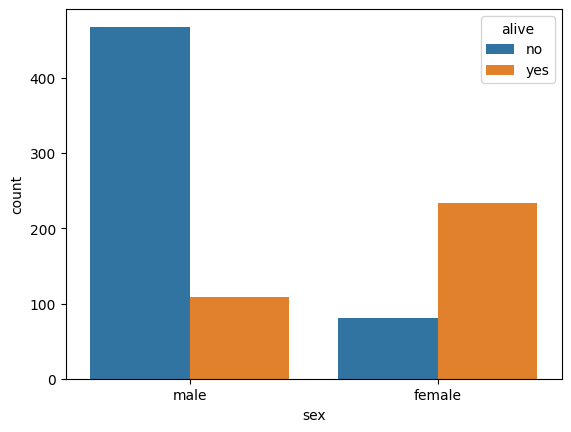

In [10]:
sns.countplot(df, x="sex", hue="alive")

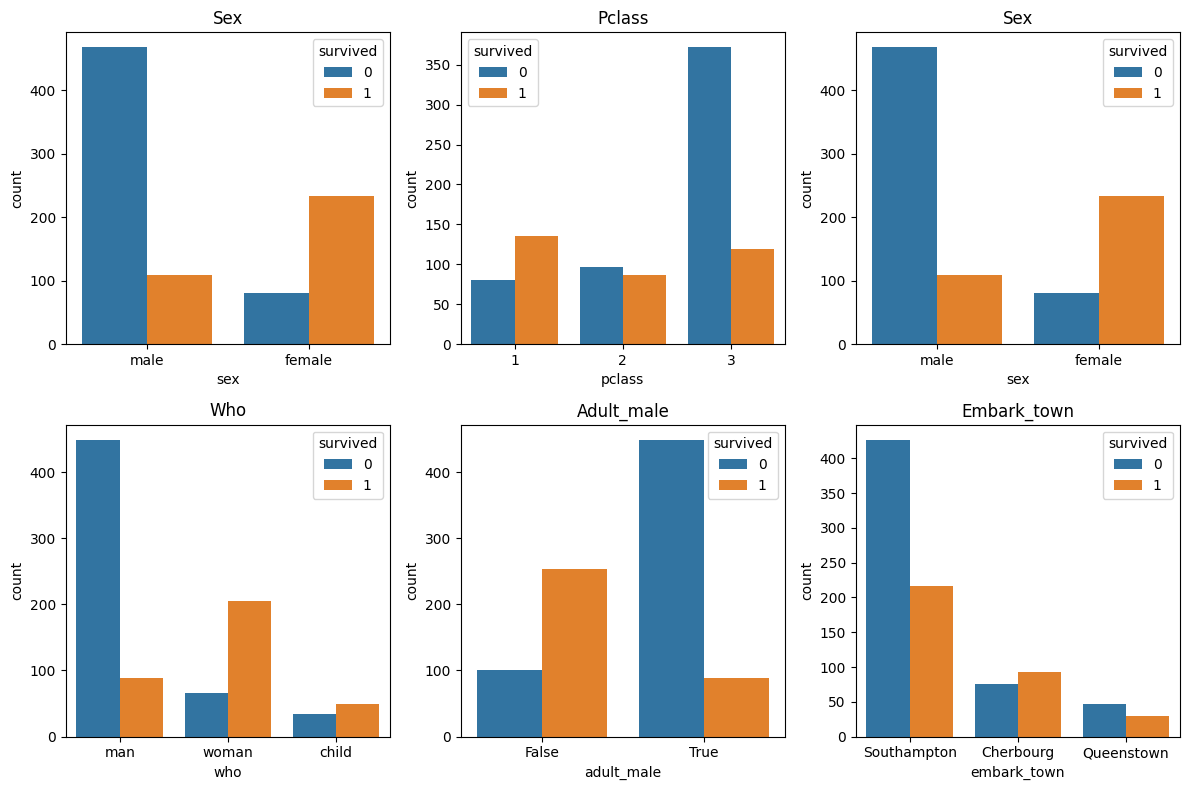

In [24]:
column_names  = list(df[["sex","pclass","sex","who","adult_male",'embark_town']].columns)

fig, subplot = plt.subplots(2,3, figsize=(12,8))
for row in range(0,2):
    for col in range(0,3):
        index = row * 3 + col
        plot = subplot[row][col]
        plot.set_title(column_names[index].capitalize())
        sns.countplot(x=df[column_names[index]], hue=df["survived"], ax=plot)
plt.tight_layout()        

In [20]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [26]:
df["sex"] = df["sex"].apply(lambda x : 1 if x=="female" else 0)

In [27]:
X = df[["pclass","sex"]]
y = df["survived"]

In [33]:
X_train,X_test, y_train, y_test = train_test_split(X,y)

In [34]:
models = (("Logistic", LogisticRegression()),
          ("KNN",KNeighborsClassifier()),
          ("Tree",DecisionTreeClassifier()))

In [35]:
for model_name, model in models:
    model.fit(X_train,y_train)
    print(model_name, model.score(X_test,y_test))

Logistic 0.7488789237668162
KNN 0.7488789237668162
Tree 0.7488789237668162
